# Peak Hour Prediction Evaluation

**Objective:**
- Evaluate peak hour prediction accuracy
- Period: BF-9 to Black Friday (2016-2024)
- Criteria: Within ±1 hour = correct

**Method:**
1. For each year (2016-2024)
2. For each day (BF-9 to BF)
3. Predict peak hour using Elastic Net model
4. Compare with actual peak hour
5. Calculate accuracy

In [1]:
import pandas as pd
import numpy as np
import pickle
from datetime import datetime, timedelta
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')
print("✓ Libraries loaded")

✓ Libraries loaded


## Configuration

In [2]:
# Features
FEATURES = [
    'mw_lag_8760h', 'mw_lag_17520h', 'mw_lag_26280h', 'mw_lag_35040h',  # Annual
    'mw_lag_72h', 'mw_lag_96h', 'mw_lag_120h', 'mw_lag_144h',
    'mw_lag_168h', 'mw_lag_192h', 'mw_lag_216h',  # Weekly
    'is_blackfriday', 'is_thanksgiving'
]

# Evaluation years
EVAL_YEARS = list(range(2016, 2025))

print(f"Evaluation years: {EVAL_YEARS}")
print(f"Features: {len(FEATURES)}")

Evaluation years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Features: 13


## Helper Functions

In [3]:
def get_black_friday(year):
    """Returns the Black Friday date for a given year"""
    nov_first = datetime(year, 11, 1)
    days_until_thursday = (3 - nov_first.weekday()) % 7
    first_thursday = nov_first + timedelta(days=days_until_thursday)
    thanksgiving = first_thursday + timedelta(weeks=3)
    black_friday = thanksgiving + timedelta(days=1)
    return black_friday

# Test
for year in EVAL_YEARS:
    bf = get_black_friday(year)
    print(f"{year}: {bf.strftime('%Y-%m-%d (%A)')}")

2016: 2016-11-25 (Friday)
2017: 2017-11-24 (Friday)
2018: 2018-11-23 (Friday)
2019: 2019-11-29 (Friday)
2020: 2020-11-27 (Friday)
2021: 2021-11-26 (Friday)
2022: 2022-11-25 (Friday)
2023: 2023-11-24 (Friday)
2024: 2024-11-29 (Friday)


## Load Models

In [4]:
# Load trained models
models_dir = Path('../models')

# Load metadata
with open(models_dir / 'model_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

load_areas = metadata['load_areas']

# Load models
models = {}
for area in load_areas:
    model_path = models_dir / f"elasticnet_{area}.pkl"
    with open(model_path, 'rb') as f:
        models[area] = pickle.load(f)

print(f"✓ Loaded {len(models)} models")
print(f"Load areas: {load_areas}")

✓ Loaded 29 models
Load areas: ['AECO', 'AEPAPT', 'AEPIMP', 'AEPKPT', 'AEPOPT', 'AP', 'BC', 'CE', 'DAY', 'DEOK', 'DOM', 'DPLCO', 'DUQ', 'EASTON', 'EKPC', 'JC', 'ME', 'OE', 'OVEC', 'PAPWR', 'PE', 'PEPCO', 'PLCO', 'PN', 'PS', 'RECO', 'SMECO', 'UGI', 'VMEU']


## Load Data

In [5]:
# Load historical data with features
print("Loading data...")
df = pd.read_parquet('../dataset/preprocessed/full_year_features.parquet')
df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'])

print(f"Data loaded: {len(df):,} rows")
print(f"Date range: {df['datetime_beginning_ept'].min()} to {df['datetime_beginning_ept'].max()}")
print(f"Load areas: {df['load_area'].nunique()}")

Loading data...
Data loaded: 3,367,288 rows
Date range: 2012-01-01 00:00:00 to 2025-11-13 23:00:00
Load areas: 34


## Predict Peak Hours

In [6]:
# Predict peak hours for all years and days
results = []

for year in EVAL_YEARS:
    bf_date = get_black_friday(year)
    
    print(f"\n{'='*80}")
    print(f"Year {year}: Black Friday = {bf_date.strftime('%Y-%m-%d')}")
    print(f"{'='*80}")
    
    # Evaluate BF-9 to BF
    for days_before in range(9, -1, -1):
        target_date = bf_date - timedelta(days=days_before)
        
        # Get data for this date
        date_data = df[
            (df['datetime_beginning_ept'] >= target_date) &
            (df['datetime_beginning_ept'] < target_date + timedelta(days=1))
        ].copy()
        
        if len(date_data) == 0:
            print(f"  {target_date.strftime('%Y-%m-%d')}: No data")
            continue
        
        print(f"  {target_date.strftime('%Y-%m-%d')} (BF-{days_before}): ", end="")
        
        # For each area
        for area in load_areas:
            area_data = date_data[date_data['load_area'] == area].copy()
            
            if len(area_data) == 0:
                continue
            
            # Get actual peak hour
            actual_peak_idx = area_data['mw'].idxmax()
            actual_peak_hour = int(area_data.loc[actual_peak_idx, 'hour'])
            
            # Prepare features for prediction
            X = area_data[FEATURES]
            
            # Check for missing values
            if X.isnull().any().any():
                # Fill with 0 for missing values
                X = X.fillna(0)
            
            # Predict
            model = models[area]
            predictions = model.predict(X)
            
            # Predicted peak hour
            predicted_peak_idx = np.argmax(predictions)
            predicted_peak_hour = int(area_data.iloc[predicted_peak_idx]['hour'])
            
            # Calculate difference
            diff = abs(predicted_peak_hour - actual_peak_hour)
            is_correct = diff <= 1  # Within ±1 hour
            
            # Store result
            results.append({
                'year': year,
                'date': target_date,
                'days_before_bf': days_before,
                'area': area,
                'actual_peak_hour': actual_peak_hour,
                'predicted_peak_hour': predicted_peak_hour,
                'difference': diff,
                'is_correct': is_correct
            })
        
        print(f"{len([r for r in results if r['date'] == target_date])} areas evaluated")

# Create DataFrame
results_df = pd.DataFrame(results)

print(f"\n{'='*80}")
print(f"✓ Evaluation complete")
print(f"{'='*80}")
print(f"Total predictions: {len(results_df)}")
print(f"Years: {results_df['year'].nunique()}")
print(f"Dates: {results_df['date'].nunique()}")
print(f"Areas: {results_df['area'].nunique()}")


Year 2016: Black Friday = 2016-11-25
  2016-11-16 (BF-9): 26 areas evaluated
  2016-11-17 (BF-8): 26 areas evaluated
  2016-11-18 (BF-7): 26 areas evaluated
  2016-11-19 (BF-6): 26 areas evaluated
  2016-11-20 (BF-5): 26 areas evaluated
  2016-11-21 (BF-4): 26 areas evaluated
  2016-11-22 (BF-3): 26 areas evaluated
  2016-11-23 (BF-2): 26 areas evaluated
  2016-11-24 (BF-1): 26 areas evaluated
  2016-11-25 (BF-0): 26 areas evaluated

Year 2017: Black Friday = 2017-11-24
  2017-11-15 (BF-9): 28 areas evaluated
  2017-11-16 (BF-8): 28 areas evaluated
  2017-11-17 (BF-7): 28 areas evaluated
  2017-11-18 (BF-6): 28 areas evaluated
  2017-11-19 (BF-5): 28 areas evaluated
  2017-11-20 (BF-4): 28 areas evaluated
  2017-11-21 (BF-3): 28 areas evaluated
  2017-11-22 (BF-2): 28 areas evaluated
  2017-11-23 (BF-1): 28 areas evaluated
  2017-11-24 (BF-0): 28 areas evaluated

Year 2018: Black Friday = 2018-11-23
  2018-11-14 (BF-9): 28 areas evaluated
  2018-11-15 (BF-8): 28 areas evaluated
  2018

## Overall Accuracy

In [7]:
# Overall accuracy
overall_accuracy = results_df['is_correct'].mean() * 100

print(f"{'='*80}")
print(f"OVERALL PEAK HOUR PREDICTION ACCURACY")
print(f"{'='*80}")
print(f"Accuracy (±1 hour): {overall_accuracy:.2f}%")
print(f"Correct predictions: {results_df['is_correct'].sum()}/{len(results_df)}")
print(f"\nDifference distribution:")
print(results_df['difference'].value_counts().sort_index())

# Average difference
avg_diff = results_df['difference'].mean()
print(f"\nAverage difference: {avg_diff:.2f} hours")

OVERALL PEAK HOUR PREDICTION ACCURACY
Accuracy (±1 hour): 55.74%
Correct predictions: 1427/2560

Difference distribution:
difference
0     948
1     479
2      79
3      35
4      16
5      27
6      40
7      97
8      98
9     101
10    227
11    240
12     81
13     54
14      9
15      3
16      3
17      6
18      8
19      3
20      2
21      1
22      2
23      1
Name: count, dtype: int64

Average difference: 4.21 hours


## Accuracy by Year

In [8]:
# Accuracy by year
year_accuracy = results_df.groupby('year').agg({
    'is_correct': ['mean', 'sum', 'count'],
    'difference': 'mean'
}).round(4)

year_accuracy.columns = ['accuracy', 'correct', 'total', 'avg_diff']
year_accuracy['accuracy'] = year_accuracy['accuracy'] * 100

print(f"{'='*80}")
print(f"ACCURACY BY YEAR")
print(f"{'='*80}")
print(year_accuracy.to_string())

ACCURACY BY YEAR
      accuracy  correct  total  avg_diff
year                                    
2016     51.92      135    260    4.7692
2017     57.50      161    280    3.8929
2018     60.00      168    280    3.7107
2019     58.28      169    290    3.9000
2020     50.69      147    290    4.7276
2021     55.52      161    290    4.4276
2022     55.17      160    290    4.4276
2023     55.52      161    290    4.1897
2024     56.90      165    290    3.9069


## Accuracy by Area

In [9]:
# Accuracy by area
area_accuracy = results_df.groupby('area').agg({
    'is_correct': ['mean', 'sum', 'count'],
    'difference': 'mean'
}).round(4)

area_accuracy.columns = ['accuracy', 'correct', 'total', 'avg_diff']
area_accuracy['accuracy'] = area_accuracy['accuracy'] * 100
area_accuracy = area_accuracy.sort_values('accuracy', ascending=False)

print(f"{'='*80}")
print(f"ACCURACY BY AREA (Top 10 and Bottom 10)")
print(f"{'='*80}")
print("\nTop 10:")
print(area_accuracy.head(10).to_string())
print("\nBottom 10:")
print(area_accuracy.tail(10).to_string())

ACCURACY BY AREA (Top 10 and Bottom 10)

Top 10:
       accuracy  correct  total  avg_diff
area                                     
RECO      98.89       89     90    0.2667
PS        98.89       89     90    0.1778
VMEU      96.25       77     80    0.3625
JC        95.56       86     90    0.6222
AECO      95.00       76     80    0.6125
CE        91.11       82     90    0.9333
PE        77.78       70     90    2.0333
DUQ       67.78       61     90    2.5556
UGI       66.67       60     90    3.0222
PEPCO     54.44       49     90    4.1889

Bottom 10:
        accuracy  correct  total  avg_diff
area                                      
AP         43.33       39     90    5.7889
DEOK       43.33       39     90    5.2667
EKPC       43.33       39     90    5.8444
AEPKPT     41.11       37     90    5.9222
AEPOPT     38.89       35     90    5.4222
DAY        34.44       31     90    5.4000
AEPIMP     27.78       25     90    5.6000
PAPWR      25.56       23     90    6.4000
PN   

## Accuracy by Days Before BF

In [10]:
# Accuracy by days before BF
days_accuracy = results_df.groupby('days_before_bf').agg({
    'is_correct': ['mean', 'sum', 'count'],
    'difference': 'mean'
}).round(4)

days_accuracy.columns = ['accuracy', 'correct', 'total', 'avg_diff']
days_accuracy['accuracy'] = days_accuracy['accuracy'] * 100

print(f"{'='*80}")
print(f"ACCURACY BY DAYS BEFORE BLACK FRIDAY")
print(f"{'='*80}")
print(days_accuracy.to_string())

ACCURACY BY DAYS BEFORE BLACK FRIDAY
                accuracy  correct  total  avg_diff
days_before_bf                                    
0                  69.92      179    256    3.0156
1                  23.83       61    256    5.5508
2                  50.39      129    256    4.7500
3                  60.16      154    256    3.6445
4                  53.52      137    256    4.5195
5                  52.34      134    256    5.2461
6                  64.45      165    256    3.5781
7                  55.08      141    256    4.2891
8                  67.58      173    256    3.3945
9                  60.16      154    256    4.1484


## Visualizations

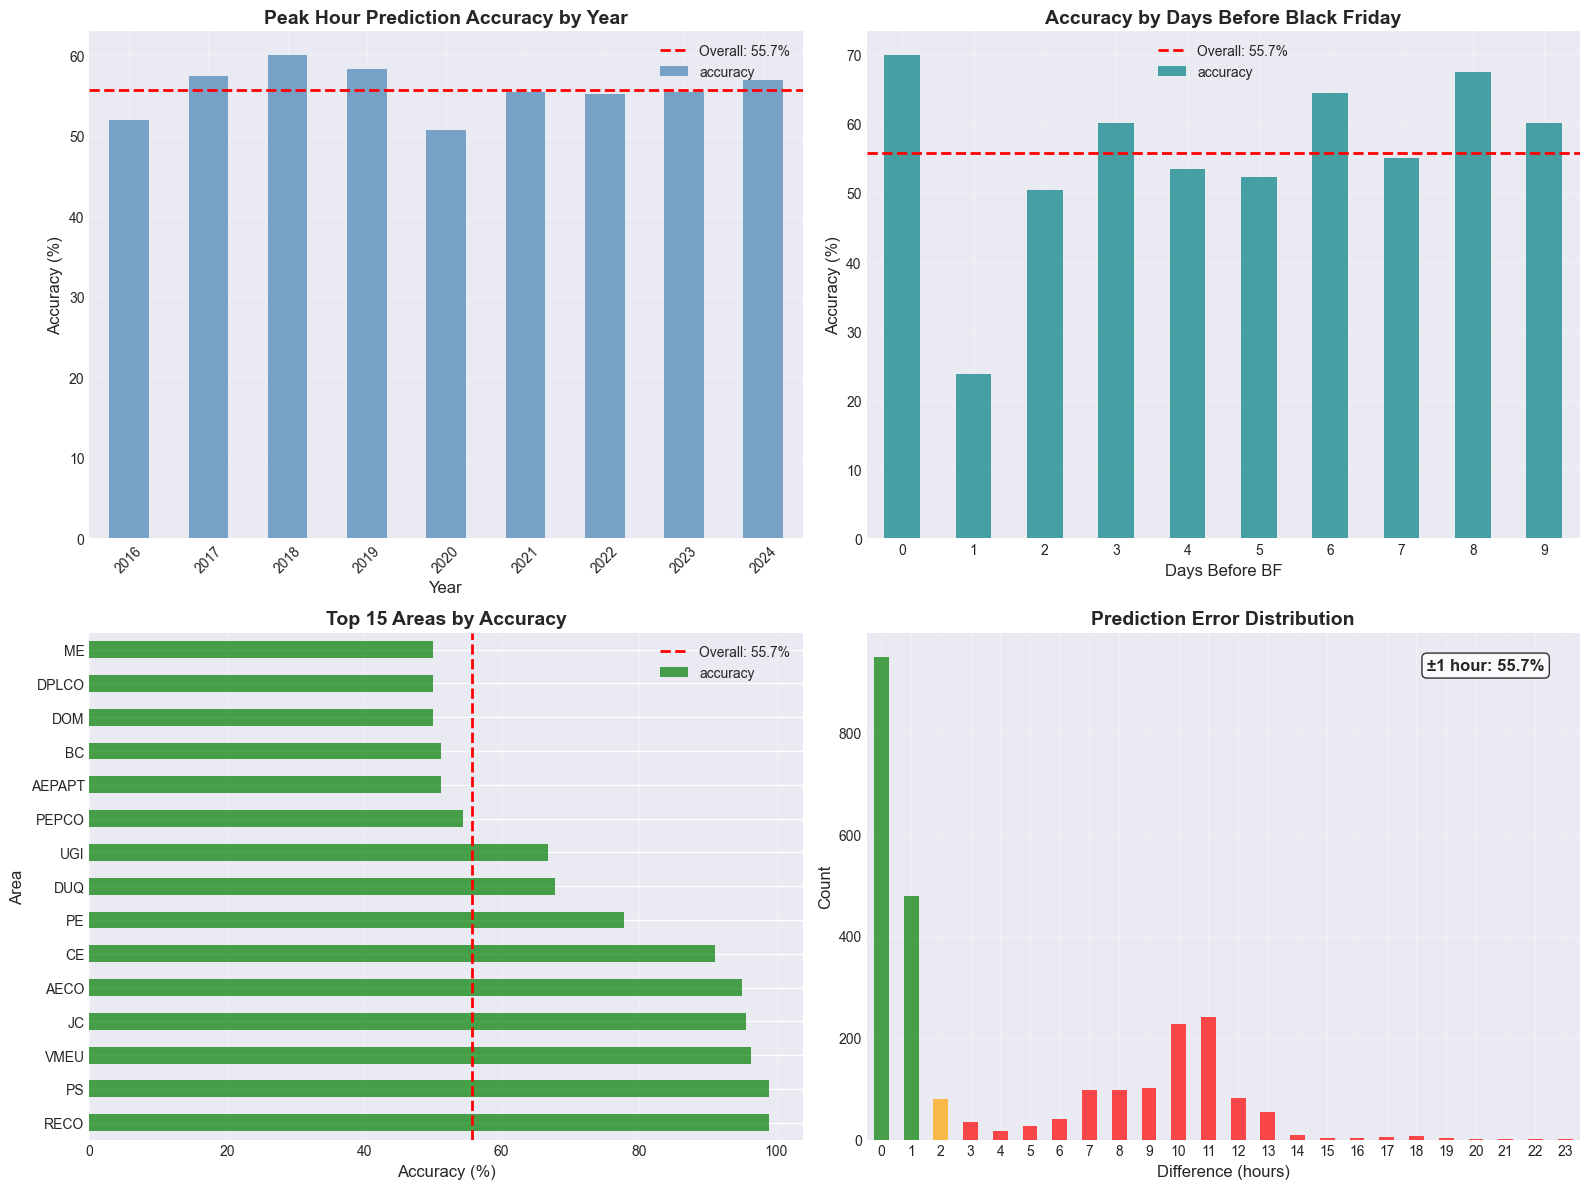

In [11]:
# 1. Overall accuracy visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Accuracy by year
ax1 = axes[0, 0]
year_accuracy['accuracy'].plot(kind='bar', ax=ax1, color='steelblue', alpha=0.7)
ax1.set_title('Peak Hour Prediction Accuracy by Year', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.axhline(overall_accuracy, color='red', linestyle='--', linewidth=2, label=f'Overall: {overall_accuracy:.1f}%')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

# Accuracy by days before BF
ax2 = axes[0, 1]
days_accuracy['accuracy'].plot(kind='bar', ax=ax2, color='teal', alpha=0.7)
ax2.set_title('Accuracy by Days Before Black Friday', fontsize=14, fontweight='bold')
ax2.set_xlabel('Days Before BF', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.axhline(overall_accuracy, color='red', linestyle='--', linewidth=2, label=f'Overall: {overall_accuracy:.1f}%')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

# Top 15 areas by accuracy
ax3 = axes[1, 0]
area_accuracy.head(15)['accuracy'].plot(kind='barh', ax=ax3, color='green', alpha=0.7)
ax3.set_title('Top 15 Areas by Accuracy', fontsize=14, fontweight='bold')
ax3.set_xlabel('Accuracy (%)', fontsize=12)
ax3.set_ylabel('Area', fontsize=12)
ax3.axvline(overall_accuracy, color='red', linestyle='--', linewidth=2, label=f'Overall: {overall_accuracy:.1f}%')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='x')

# Difference distribution
ax4 = axes[1, 1]
diff_counts = results_df['difference'].value_counts().sort_index()
colors = ['green' if x <= 1 else 'orange' if x <= 2 else 'red' for x in diff_counts.index]
diff_counts.plot(kind='bar', ax=ax4, color=colors, alpha=0.7)
ax4.set_title('Prediction Error Distribution', fontsize=14, fontweight='bold')
ax4.set_xlabel('Difference (hours)', fontsize=12)
ax4.set_ylabel('Count', fontsize=12)
ax4.grid(True, alpha=0.3)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)

# Add annotation
correct_pct = (diff_counts[diff_counts.index <= 1].sum() / diff_counts.sum() * 100)
ax4.text(0.95, 0.95, f'±1 hour: {correct_pct:.1f}%',
         transform=ax4.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

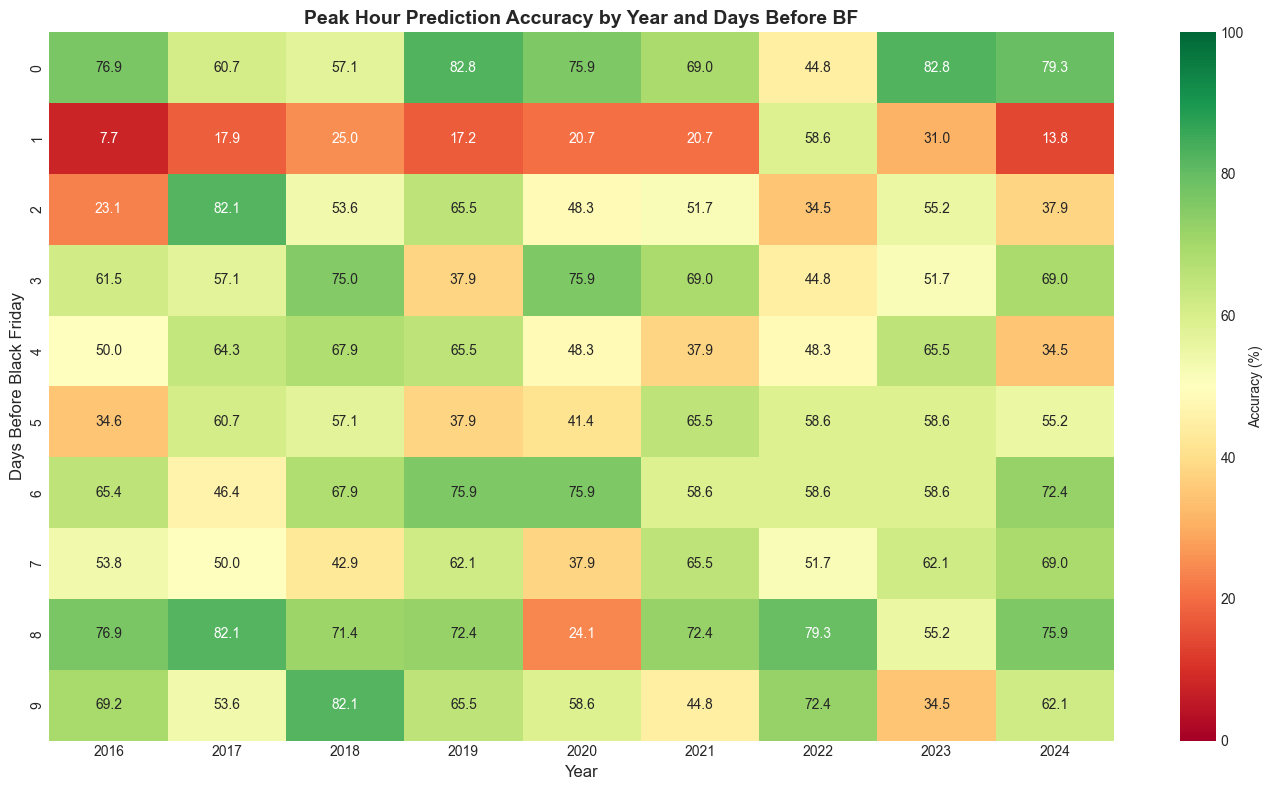

In [12]:
# 2. Heatmap: Accuracy by Year and Days Before BF
pivot_accuracy = results_df.pivot_table(
    values='is_correct',
    index='days_before_bf',
    columns='year',
    aggfunc='mean'
) * 100

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot_accuracy, annot=True, fmt='.1f', cmap='RdYlGn', 
            vmin=0, vmax=100, ax=ax, cbar_kws={'label': 'Accuracy (%)'})
ax.set_title('Peak Hour Prediction Accuracy by Year and Days Before BF', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Days Before Black Friday', fontsize=12)
plt.tight_layout()
plt.show()

## Save Results

In [ ]:
# Save detailed results
output_path = Path('../results/peak_hour_evaluation_elasticnet.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(output_path, index=False)

print(f"✓ Results saved to: {output_path}")
print(f"  Total rows: {len(results_df)}")

# Save summary
summary = {
    'overall_accuracy': overall_accuracy,
    'total_predictions': len(results_df),
    'correct_predictions': results_df['is_correct'].sum(),
    'avg_difference': avg_diff,
    'years_evaluated': EVAL_YEARS,
    'areas_evaluated': len(load_areas)
}

print(f"\n{'='*80}")
print(f"SUMMARY")
print(f"{'='*80}")
for key, value in summary.items():
    print(f"{key}: {value}")

✓ Results saved to: ../results/peak_hour_evaluation.csv
  Total rows: 2560

SUMMARY
overall_accuracy: 55.74218749999999
total_predictions: 2560
correct_predictions: 1427
avg_difference: 4.213671875
years_evaluated: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
areas_evaluated: 29
